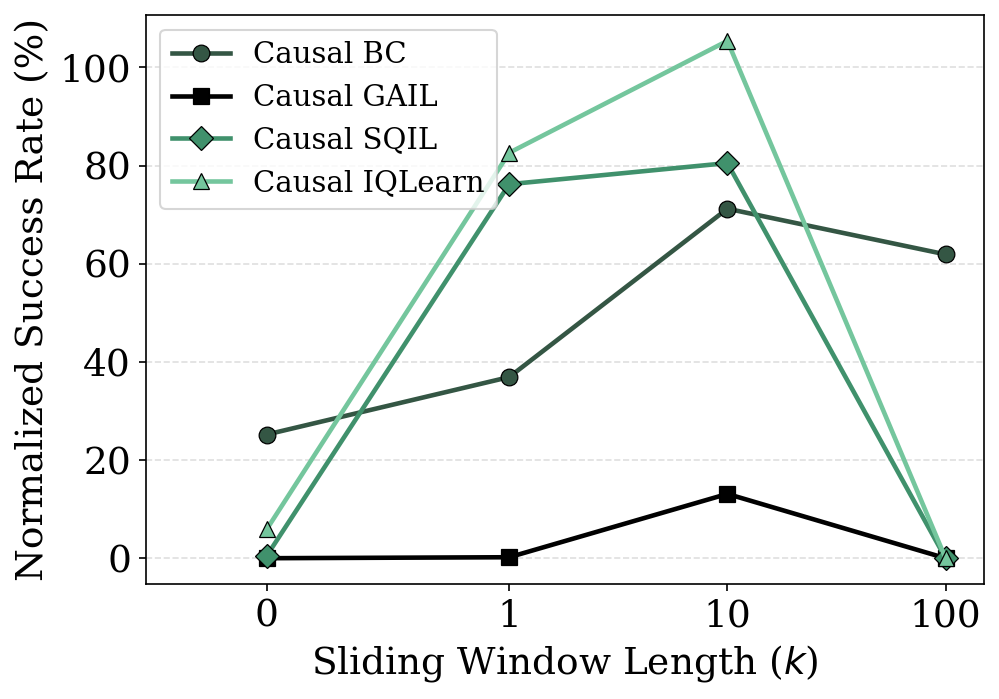

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "figure.dpi": 150,
})

PLOTS_DIR = '/home/et2842/causal/causalrl/examples/experiments/plots/ablations'
k_values = [0, 1, 10, 100]

# ── AntMaze Large: Norm SR (%) ──
antlarge = {
    "Causal BC":      [25.2, 36.9, 71.2, 61.9],
    "Causal GAIL":    [ 0.0,  0.2, 13.1,  0.0],
    "Causal SQIL":    [ 0.5, 76.2, 80.5,  0.0],
    "Causal IQLearn": [ 5.9, 82.6, 105.4, 0.0],
}

colors = {
    "Causal BC":      "#345644",
    "Causal GAIL":    "#010101",
    "Causal SQIL":    "#40916C",
    "Causal IQLearn": "#74C69D",
}

markers = {
    "Causal BC":      "o",
    "Causal GAIL":    "s",
    "Causal SQIL":    "D",
    "Causal IQLearn": "^",
}

os.makedirs(PLOTS_DIR, exist_ok=True)

# ✅ Single plot
fig, ax = plt.subplots(figsize=(7, 5))

for algo, vals in antlarge.items():
    ax.plot(
        k_values, vals,
        marker=markers[algo],
        color=colors[algo],
        label=algo,
        linewidth=2.2,
        markersize=8,
        markeredgecolor='black',
        markeredgewidth=0.6
    )

ax.set_xlabel("Sliding Window Length ($k$)")
ax.set_ylabel("Normalized Success Rate (%)")
# ax.set_title("AntMaze Large", pad=10)
ax.set_xscale("symlog", linthresh=1)
ax.set_xticks(k_values)
ax.set_xticklabels([str(k) for k in k_values])
ax.set_xlim(-0.5, 150)
ax.legend(fontsize=14)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(f'{PLOTS_DIR}/ablation_window_length.pdf', dpi=300, bbox_inches='tight')
plt.show()